In [69]:
import re

import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use(hep.style.LHCb2)

In [70]:
def parse_tagging_power(filename, category):
    with open(filename, 'r') as f:
        content = f.read()
    
    blocks = content.split("====================")
    
    for block in blocks:
        if category in block:
            # Search in the SAME block, not the next one
            match = re.search(r'Tagging power\s*:\s*\(([0-9.]+)\s*\+/-\s*([0-9.]+)\)%', block)
            if match:
                value = float(match.group(1))
                uncertainty = float(match.group(2))
                return value, uncertainty
    return None, None

In [71]:
epochs = [16, 18, 20, 21, 25]
files = []
for epoch in epochs:
    files.append(f"info_00342629_Bs_Jpsiphi_00342638_Bs_Jpsiphi__epoch_{epoch}__is_whiten_FT.txt")

In [72]:
res = {"positive":[], "negative":[]}
res_err = {"positive":[], "negative":[]}
conditions = ["positive", "negative" ]
for condition in conditions:
    for file in files:
        value, unc = parse_tagging_power(file, f"performance for {condition} 00342629")
        res[condition].append(value)
        res_err[condition].append(unc)

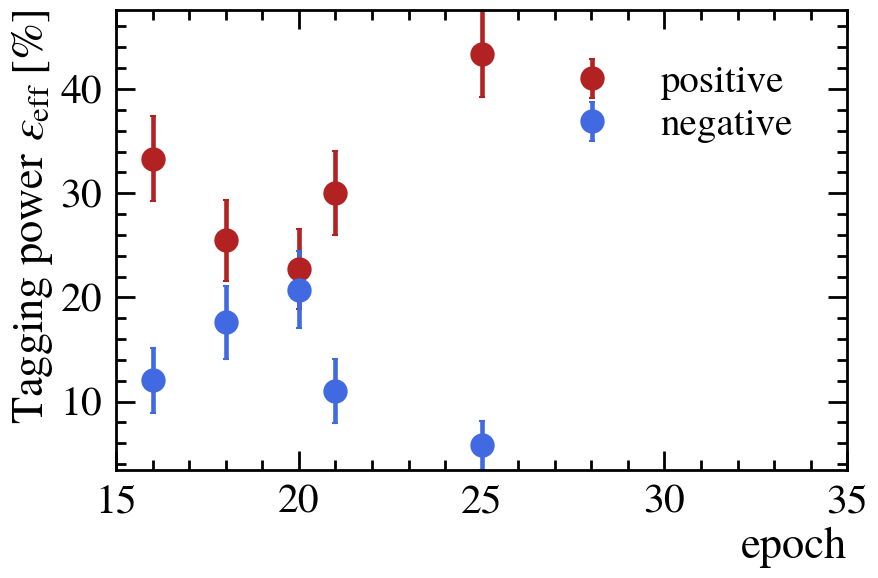

In [73]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(epochs, res["positive"], yerr=res_err["positive"], 
                    fmt='o', color="#B22222", label="positive")
ax.errorbar(epochs, res["negative"], yerr=res_err["negative"], 
                    fmt='o', color="#4169E1", label="negative")
ax.set_xlim(15, 35)
ax.set_xlabel("epoch")
ax.set_ylabel(r"Tagging power $\epsilon_\mathrm{eff}$ [%]")
ax.legend()
plt.savefig("bias_check_combined.png")

In [74]:
res = {"positive":[], "negative":[]}
res_err = {"positive":[], "negative":[]}
conditions = ["positive", "negative" ]
for condition in conditions:
    for file in files:
        value, unc = parse_tagging_power(file, f"performance for {condition} single B 00342629")
        res[condition].append(value)
        res_err[condition].append(unc)

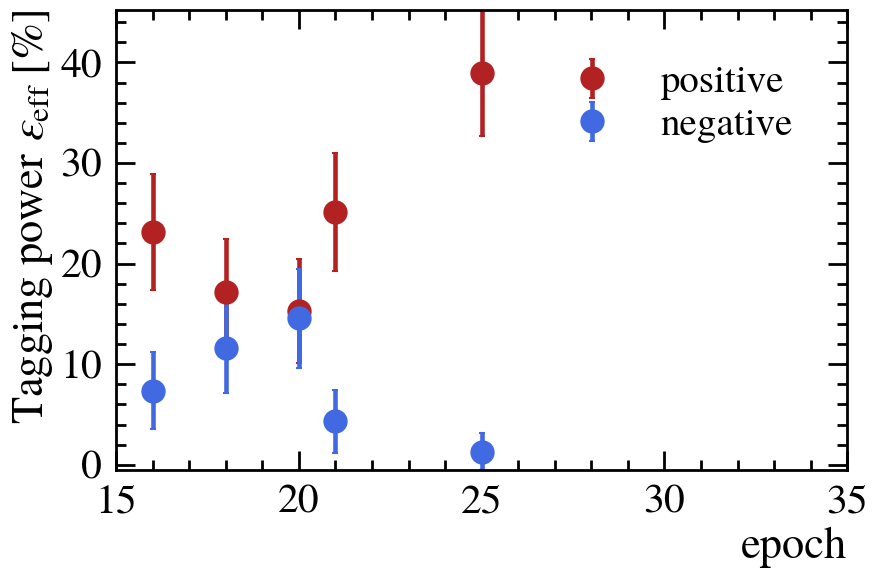

In [75]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(epochs, res["positive"], yerr=res_err["positive"], 
                    fmt='o', color="#B22222", label="positive")
ax.errorbar(epochs, res["negative"], yerr=res_err["negative"], 
                    fmt='o', color="#4169E1", label="negative")
ax.set_xlim(15, 35)
ax.set_xlabel("epoch")
ax.set_ylabel(r"Tagging power $\epsilon_\mathrm{eff}$ [%]")
ax.legend()
plt.savefig("bias_check_single.png")

In [76]:
res = {"positive":[], "negative":[]}
res_err = {"positive":[], "negative":[]}
conditions = ["positive", "negative" ]
for condition in conditions:
    for file in files:
        value, unc = parse_tagging_power(file, f"performance for {condition} double B 00342629")
        res[condition].append(value)
        res_err[condition].append(unc)

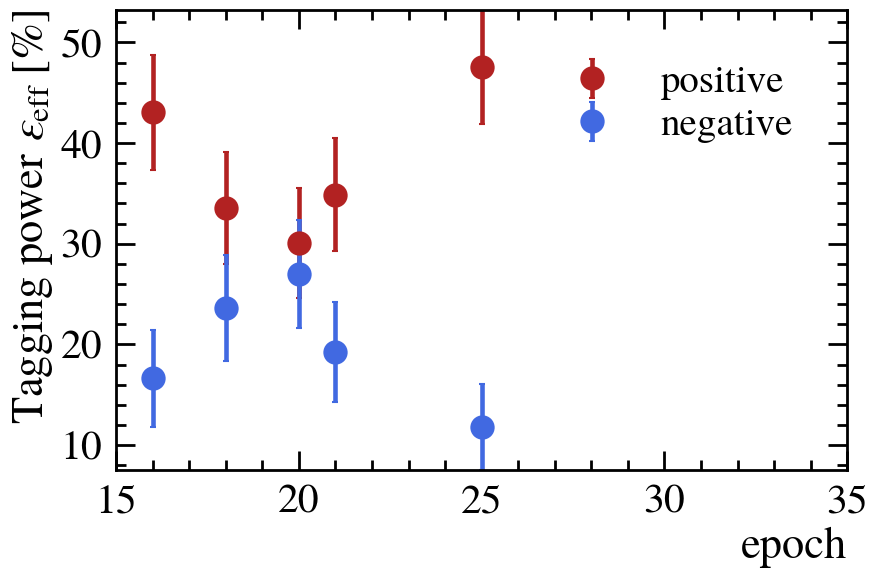

In [77]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(epochs, res["positive"], yerr=res_err["positive"], 
                    fmt='o', color="#B22222", label="positive")
ax.errorbar(epochs, res["negative"], yerr=res_err["negative"], 
                    fmt='o', color="#4169E1", label="negative")
ax.set_xlim(15, 35)
ax.set_xlabel("epoch")
ax.set_ylabel(r"Tagging power $\epsilon_\mathrm{eff}$ [%]")
ax.legend()
plt.savefig("bias_check_double.png")

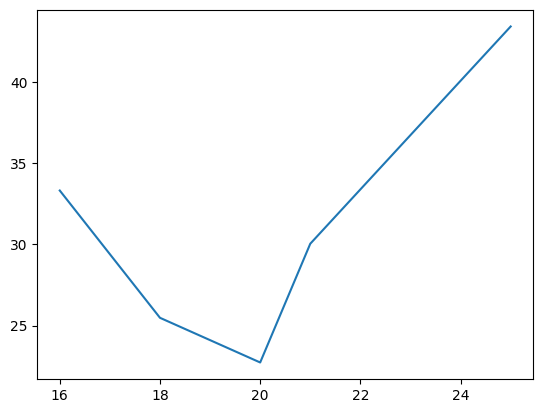

In [49]:
plt.plot(epochs, res["positive"])

In [44]:
res

{'positive': [33.3109, 25.4797, 22.7306, 30.0368, 43.4039],
 'negative': [12.0349, 17.6193, 20.7531, 11.029, 5.7956]}

In [39]:
files

['info_00342629_Bs_Jpsiphi_00342638_Bs_Jpsiphi__epoch_16__is_whiten_FT.txt',
 'info_00342629_Bs_Jpsiphi_00342638_Bs_Jpsiphi__epoch_18__is_whiten_FT.txt',
 'info_00342629_Bs_Jpsiphi_00342638_Bs_Jpsiphi__epoch_20__is_whiten_FT.txt',
 'info_00342629_Bs_Jpsiphi_00342638_Bs_Jpsiphi__epoch_21__is_whiten_FT.txt',
 'info_00342629_Bs_Jpsiphi_00342638_Bs_Jpsiphi__epoch_25__is_whiten_FT.txt']

Tagging power: (12.0349 +/- 3.1247)%


In [31]:
block

NameError: name 'block' is not defined

In [11]:
with open("info_00342629_Bs_Jpsiphi_00342638_Bs_Jpsiphi__epoch_16__is_whiten_FT.txt", 'r') as f:
        content = f.read()

In [13]:
"performance for negative 00342629" in content.split("====================")[7]

False

In [15]:
content.split("====================")

['',
 '',
 '==========\nFLAVOUR TAGGING POWER \n',
 '\nTagging performance for 00342629_Bs_Jpsiphi_00342638_Bs_Jpsiphi__epoch_16__is_whiten (3191):\nTagging power  : (21.1862 +/- 2.6262)%\nWrong fraction : (26.9821 +/- 1.3972)%\nEpsilon        : (99.9687 +/- 2.5025)%\nDsquared       : (21.1929 +/- 2.5728)%\n',
 '\n1 B candidate present in event (1433):\nTagging power  : (13.8345 +/- 3.4753)%\nWrong fraction : (31.4027 +/- 2.3099)%\nEpsilon        : (100.0000 +/- 3.7359)%\nDsquared       : (13.8345 +/- 3.4366)%\nCorrectness ratio: (68.60 +/- 2.84)%\nWith fragmentation: (-100.00 +/- -100.00)%\nWithout fragmentation: (-100.00 +/- -100.00)%\n',
 '\n2 B candidate present in event (1690):\nTagging power  : (28.3730 +/- 3.8394)%\nWrong fraction : (23.3590 +/- 1.7434)%\nEpsilon        : (99.9409 +/- 3.4365)%\nDsquared       : (28.3898 +/- 3.7156)%\nCorrectness ratio: (76.64 +/- 2.83)%\nWith fragmentation: (-100.00 +/- -100.00)%\nWithout fragmentation: (-100.00 +/- -100.00)%\n',
 '\nSignal has 

In [21]:
"\nTagging performance for negative 00338660" in content.split("====================")[9]

False

In [22]:
content.split("====================")[9]

'\nTagging performance for negative 00342629_Bs_Jpsiphi_00342638_Bs_Jpsiphi__epoch_16__is_whiten (1620):\nTagging power  : (12.0349 +/- 3.1247)%\nWrong fraction : (32.6543 +/- 2.2311)%\nEpsilon        : (100.0000 +/- 3.5136)%\nDsquared       : (12.0349 +/- 3.0959)%\nCorrectness ratio: (67.35 +/- 2.64)%\n'